## Compare Sample vs Original

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

In [2]:
original = pd.read_csv("../Data/cleanedHealthData.csv")
sample = pd.read_csv("../Data/sampleData.csv")

C:\Users\admin\AppData\Local\Temp\ipykernel_36124\171321968.py:2: DtypeWarning: Columns (1,12,18,19,24,25,26,27,29,30,31,32,33,34,36,37,38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  sample = pd.read_csv("../Data/sampleData.csv")


In [3]:
## Separate all the columns
numerical_cols = original.select_dtypes(include=['number']).columns
numerical_cols = [col for col in numerical_cols if col != 'target']

categorical_cols = list(original.select_dtypes(exclude=['number']).columns)

In [4]:
## Reset target value names for sample
sample['target'] = sample['target'].replace({1:'healthy', 0:'diseased'})

In [5]:
original['target'].value_counts(normalize=True)

target
healthy     0.70097
diseased    0.29903
Name: proportion, dtype: float64

In [6]:
sample['target'].value_counts(normalize=True)

target
healthy     0.70095
diseased    0.29905
Name: proportion, dtype: float64

## Check numerical feature distributions

In [7]:
def ssplotNums(df, df2, numerical_cols):
    
    cols = 2
    rows = len(numerical_cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))

    for i, col in enumerate(numerical_cols):
        sns.histplot(df[col], bins=30, kde=True, ax=axes[i, 0], color='blue', edgecolor='white')
        axes[i, 0].set_title(f"Original Distribution for {col}")
        
        sns.histplot(df2[col], bins=30, kde=True, ax=axes[i, 1], color='red', edgecolor='white')
        axes[i, 1].set_title(f"Sample Distribution for {col}")  

    plt.tight_layout()
    plt.show()

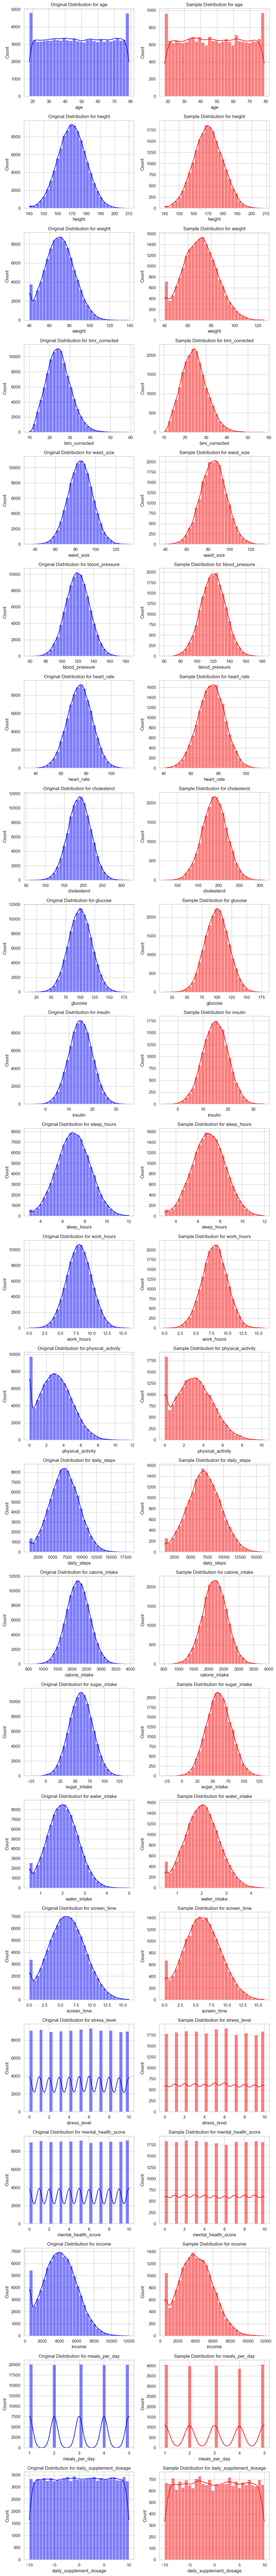

In [8]:
ssplotNums(original, sample, numerical_cols)

## Check categorical feature distributions

In [9]:
def ssplotCats(df, df2, categorical_cols):
    cols = 2
    rows = len(categorical_cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))

    for i, col in enumerate(categorical_cols):
        counts = df[col].value_counts()
        sns.barplot(data=pd.DataFrame(counts), x=counts.index, y=counts.values, hue=col, legend=False, ax=axes[i, 0], palette='colorblind')
        axes[i, 0].set_title(f"Original Histogram for {col}")

        for idx, val in enumerate(counts.values):
            axes[i, 0].text(idx, val - 0.2, f"{val:,}", ha='center', va='bottom')
            
        counts2 = df2[col].value_counts()
        sns.barplot(data=pd.DataFrame(counts2), x=counts2.index, y=counts2.values, hue=col, legend=False, ax=axes[i, 1], palette='colorblind')
        axes[i, 1].set_title(f"Sample Histogram for {col}")

        for idx, val in enumerate(counts2.values):
            axes[i, 1].text(idx, val - 0.2, f"{val:,}", ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

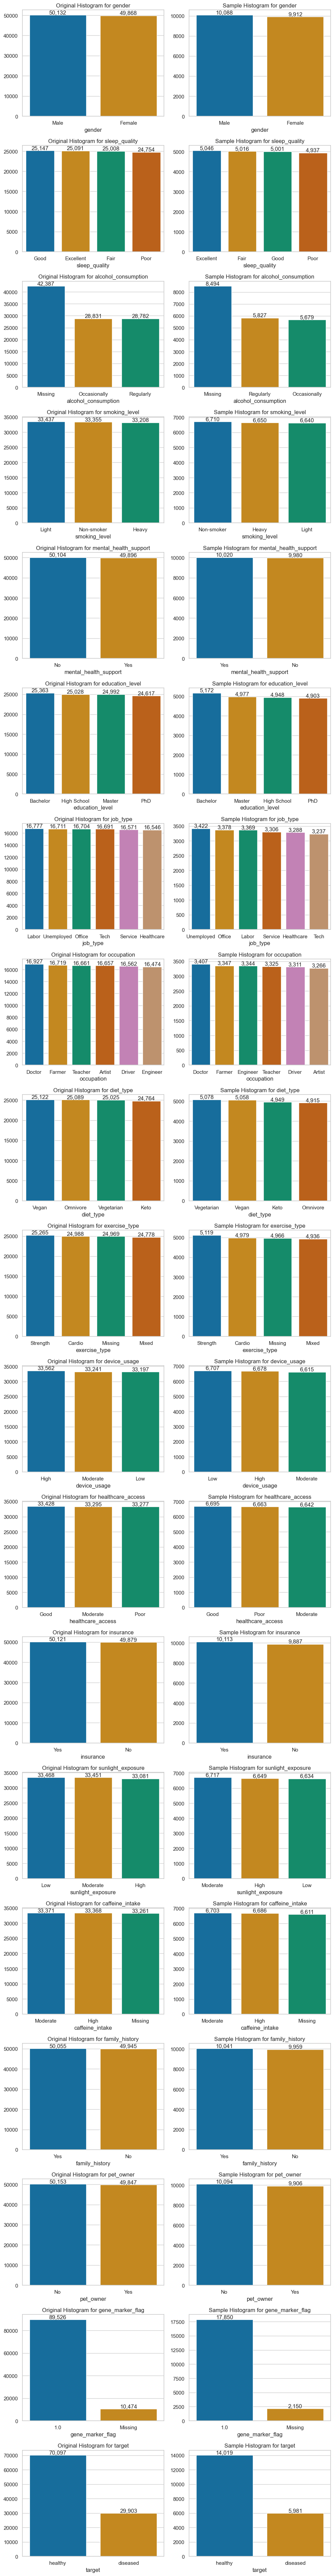

In [10]:
ssplotCats(original, sample, categorical_cols)